# Module 1
We need to present a strategic recommendation to Julia that is supported by data which she can then use for the upcoming category review however to do so we need to analyse the data to understand the current purchasing trends and behaviours. The client is particularly interested in customer segments and their chip purchasing behaviour. Consider what metrics would help describe the customers’ purchasing behaviour.

In [ ]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
pur_bhvr = pd.read_csv("QVI_purchase_behaviour.csv")
print(pur_bhvr.head())

   LYLTY_CARD_NBR               LIFESTAGE PREMIUM_CUSTOMER
0            1000   YOUNG SINGLES/COUPLES          Premium
1            1002   YOUNG SINGLES/COUPLES       Mainstream
2            1003          YOUNG FAMILIES           Budget
3            1004   OLDER SINGLES/COUPLES       Mainstream
4            1005  MIDAGE SINGLES/COUPLES       Mainstream


In [ ]:
tran_data = pd.read_excel("QVI_transaction_data.xlsx")
print(tran_data.head())

    DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
0  43390          1            1000       1         5   
1  43599          1            1307     348        66   
2  43605          1            1343     383        61   
3  43329          2            2373     974        69   
4  43330          2            2426    1038       108   

                                  PROD_NAME  PROD_QTY  TOT_SALES  
0    Natural Chip        Compny SeaSalt175g         2        6.0  
1                  CCs Nacho Cheese    175g         3        6.3  
2    Smiths Crinkle Cut  Chips Chicken 170g         2        2.9  
3    Smiths Chip Thinly  S/Cream&Onion 175g         5       15.0  
4  Kettle Tortilla ChpsHny&Jlpno Chili 150g         3       13.8  


In [4]:
# Validate the many-transactions-to-one-customer join before analysing it.
join_audit = pd.DataFrame([{
    "customer_rows": len(pur_bhvr),
    "duplicate_customer_keys": int(pur_bhvr.LYLTY_CARD_NBR.duplicated().sum()),
    "missing_customer_keys": int(pur_bhvr.LYLTY_CARD_NBR.isna().sum()),
    "transaction_rows": len(tran_data),
    "missing_transaction_keys": int(tran_data.LYLTY_CARD_NBR.isna().sum()),
    "unmatched_transaction_rows": int((~tran_data.LYLTY_CARD_NBR.isin(pur_bhvr.LYLTY_CARD_NBR)).sum()),
}])
assert join_audit[["duplicate_customer_keys", "missing_customer_keys", "missing_transaction_keys", "unmatched_transaction_rows"]].eq(0).all().all()
merged_data = tran_data.merge(pur_bhvr, on="LYLTY_CARD_NBR", how="left", validate="many_to_one", indicator=True)
assert len(merged_data) == len(tran_data) and merged_data["_merge"].eq("both").all()
assert np.isclose(merged_data.TOT_SALES.sum(), tran_data.TOT_SALES.sum())
merged_data = merged_data.drop(columns="_merge")
print(join_audit.to_string(index=False))
print(merged_data.head())


 customer_rows  duplicate_customer_keys  missing_customer_keys  transaction_rows  missing_transaction_keys  unmatched_transaction_rows
         72637                        0                      0            264836                         0                           0
    DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
0  43390          1            1000       1         5   
1  43599          1            1307     348        66   
2  43605          1            1343     383        61   
3  43329          2            2373     974        69   
4  43330          2            2426    1038       108   

                                  PROD_NAME  PROD_QTY  TOT_SALES  \
0    Natural Chip        Compny SeaSalt175g         2        6.0   
1                  CCs Nacho Cheese    175g         3        6.3   
2    Smiths Crinkle Cut  Chips Chicken 170g         2        2.9   
3    Smiths Chip Thinly  S/Cream&Onion 175g         5       15.0   
4  Kettle Tortilla ChpsHny&Jlpno Chili 150g    

In [5]:
print(len(merged_data))
print(len(tran_data))

264836
264836


In [6]:
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   DATE              264836 non-null  int64  
 1   STORE_NBR         264836 non-null  int64  
 2   LYLTY_CARD_NBR    264836 non-null  int64  
 3   TXN_ID            264836 non-null  int64  
 4   PROD_NBR          264836 non-null  int64  
 5   PROD_NAME         264836 non-null  object 
 6   PROD_QTY          264836 non-null  int64  
 7   TOT_SALES         264836 non-null  float64
 8   LIFESTAGE         264836 non-null  object 
 9   PREMIUM_CUSTOMER  264836 non-null  object 
dtypes: float64(1), int64(6), object(3)
memory usage: 20.2+ MB


Date column should be in datetime format

In [7]:
from datetime import date, timedelta
start = date(1899,12,30)

new_date_format = []

for date in merged_data["DATE"]:
    delta = timedelta(date)
    new_date_format.append(start + delta)

In [8]:
merged_data["DATE"] = pd.to_datetime(pd.Series(new_date_format))
print(merged_data["DATE"].dtype)

datetime64[ns]


Next, checking the prod_name column to make sure all items are chips

In [9]:
merged_data["PROD_NAME"].unique()

array(['Natural Chip        Compny SeaSalt175g',
       'CCs Nacho Cheese    175g',
       'Smiths Crinkle Cut  Chips Chicken 170g',
       'Smiths Chip Thinly  S/Cream&Onion 175g',
       'Kettle Tortilla ChpsHny&Jlpno Chili 150g',
       'Old El Paso Salsa   Dip Tomato Mild 300g',
       'Smiths Crinkle Chips Salt & Vinegar 330g',
       'Grain Waves         Sweet Chilli 210g',
       'Doritos Corn Chip Mexican Jalapeno 150g',
       'Grain Waves Sour    Cream&Chives 210G',
       'Kettle Sensations   Siracha Lime 150g',
       'Twisties Cheese     270g', 'WW Crinkle Cut      Chicken 175g',
       'Thins Chips Light&  Tangy 175g', 'CCs Original 175g',
       'Burger Rings 220g', 'NCC Sour Cream &    Garden Chives 175g',
       'Doritos Corn Chip Southern Chicken 150g',
       'Cheezels Cheese Box 125g', 'Smiths Crinkle      Original 330g',
       'Infzns Crn Crnchers Tangy Gcamole 110g',
       'Kettle Sea Salt     And Vinegar 175g',
       'Smiths Chip Thinly  Cut Original 175g', 'K

In [10]:
split_prods = merged_data["PROD_NAME"].str.replace(r'([0-9]+[gG])','').str.replace(r'[^\w]', ' ').str.split()

In [11]:
word_counts = {}

def count_words(line):
    for word in line:
        if word not in word_counts:
            word_counts[word] = 1
        else:
            word_counts[word] += 1
            
split_prods.apply(lambda line: count_words(line))
print(pd.Series(word_counts).sort_values(ascending=False))

175g        60561
Chips       49770
150g        41633
Kettle      41288
&           35565
            ...  
Sunbites     1432
Pc           1431
NCC          1419
Garden       1419
Fries        1418
Length: 220, dtype: int64


Removing Salsa products

In [12]:
merged_data = merged_data[~merged_data["PROD_NAME"].str.contains(r"[Ss]alsa")]

In [13]:
print(merged_data.describe(), '\n')
print(merged_data.info())

                                DATE      STORE_NBR  LYLTY_CARD_NBR  \
count                         246742  246742.000000    2.467420e+05   
mean   2018-12-30 01:19:01.211467520     135.051098    1.355310e+05   
min              2018-07-01 00:00:00       1.000000    1.000000e+03   
25%              2018-09-30 00:00:00      70.000000    7.001500e+04   
50%              2018-12-30 00:00:00     130.000000    1.303670e+05   
75%              2019-03-31 00:00:00     203.000000    2.030840e+05   
max              2019-06-30 00:00:00     272.000000    2.373711e+06   
std                              NaN      76.787096    8.071528e+04   

             TXN_ID       PROD_NBR       PROD_QTY      TOT_SALES  
count  2.467420e+05  246742.000000  246742.000000  246742.000000  
mean   1.351311e+05      56.351789       1.908062       7.321322  
min    1.000000e+00       1.000000       1.000000       1.700000  
25%    6.756925e+04      26.000000       2.000000       5.800000  
50%    1.351830e+05      

In [14]:
merged_data["PROD_QTY"].value_counts(bins=4).sort_index()

(0.8, 50.75]       246740
(50.75, 100.5]          0
(100.5, 150.25]         0
(150.25, 200.0]         2
Name: count, dtype: int64

From the binning above we see that PROD_QTY values above 50.75

In [15]:
merged_data.sort_values(by="PROD_QTY", ascending=False).head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0,OLDER FAMILIES,Premium
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0,OLDER FAMILIES,Premium
135225,2019-05-15,46,46296,42138,81,Pringles Original Crisps 134g,5,18.5,RETIREES,Budget
69523,2019-05-15,71,71142,69852,96,WW Original Stacked Chips 160g,5,9.5,OLDER FAMILIES,Premium
69502,2018-08-18,55,55144,49328,44,Thins Chips Light& Tangy 175g,5,16.5,OLDER FAMILIES,Premium


Two `PROD_QTY=200` records belong to one customer. We inspect these exact rows and remove only them; legitimate purchases of five packs remain.


In [16]:
quantity_outliers = merged_data.loc[merged_data.PROD_QTY.gt(5),
    ["DATE", "STORE_NBR", "LYLTY_CARD_NBR", "TXN_ID", "PROD_NAME", "PROD_QTY", "TOT_SALES"]]
assert len(quantity_outliers) == 2 and quantity_outliers.PROD_QTY.eq(200).all()
merged_data = merged_data.loc[~merged_data.index.isin(quantity_outliers.index)].copy()
print(quantity_outliers.to_string(index=False))
print("retained rows:", len(merged_data))


      DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID                        PROD_NAME  PROD_QTY  TOT_SALES
2018-08-19        226          226000  226201 Dorito Corn Chp     Supreme 380g       200      650.0
2019-05-20        226          226000  226210 Dorito Corn Chp     Supreme 380g       200      650.0
retained rows: 246740


In [17]:
len(merged_data[merged_data["LYLTY_CARD_NBR"] == 226000])

0

In [18]:
merged_data["DATE"].describe()

count                           246740
mean     2018-12-30 01:18:58.448569344
min                2018-07-01 00:00:00
25%                2018-09-30 00:00:00
50%                2018-12-30 00:00:00
75%                2019-03-31 00:00:00
max                2019-06-30 00:00:00
Name: DATE, dtype: object

Instead of 365, the DATE column only has 364 unique values. 1 is missing.

In [19]:
pd.date_range(start=merged_data["DATE"].min(), end=merged_data["DATE"].max()).difference(merged_data["DATE"])

DatetimeIndex(['2018-12-25'], dtype='datetime64[ns]', freq='D')

Using the difference method we see that 2018-12-25 was the missing date.

In [20]:
check_null_date = pd.merge(pd.Series(pd.date_range(start=merged_data["DATE"].min(), end=merged_data["DATE"].max()), name="DATE"), merged_data, on="DATE", how="left")

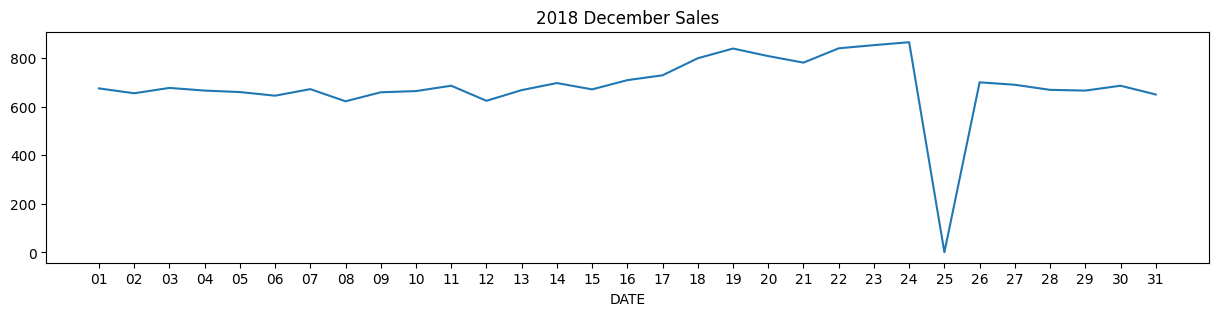

In [21]:
trans_by_date = check_null_date["DATE"].value_counts()
dec = trans_by_date[(trans_by_date.index >= pd.Timestamp(2018,12,1)) & (trans_by_date.index < pd.Timestamp(2019,1,1))].sort_index()
dec.index = dec.index.strftime('%d')
ax = dec.plot(figsize=(15,3))
ax.set_xticks(np.arange(len(dec)))
ax.set_xticklabels(dec.index)
plt.title("2018 December Sales")
plt.savefig("2018 December Sales.png", bbox_inches="tight")
plt.show()

In [22]:
check_null_date["DATE"].value_counts().sort_values().head()

DATE
2018-12-25      1
2019-06-13    607
2018-09-22    609
2018-11-25    610
2018-10-18    611
Name: count, dtype: int64

The date with the no transaction falls on Christmas day, the day when the store is closed. Knowing there's no anomaly in this, we leave it be.

Next, we'll explore product pack sizes

count    246740.000000
mean        175.583521
std          59.432118
min          70.000000
25%         150.000000
50%         170.000000
75%         175.000000
max         380.000000
Name: 0, dtype: float64
missing pack sizes: 0


<Axes: ylabel='Frequency'>

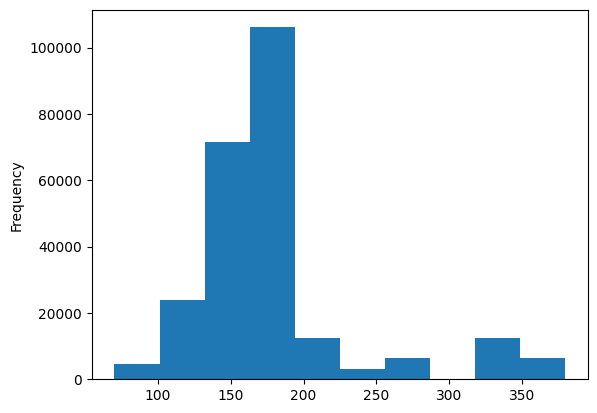

In [23]:
pack_sizes = pd.to_numeric(merged_data["PROD_NAME"].str.extract(r"(\d+)\s*[gG](?:\b|$)")[0], errors="coerce")
print(pack_sizes.describe())
print("missing pack sizes:", int(pack_sizes.isna().sum()))
pack_sizes.plot.hist()


Product pack size looks reasonable with highest transaction frequency in mid-sized pack. Smallest size is 70g, and biggest size is 380g.

Next, we will explore the product brand names

In [24]:
merged_data["PROD_NAME"].str.split().str[0].value_counts().sort_index()

PROD_NAME
Burger         1564
CCs            4551
Cheetos        2927
Cheezels       4603
Cobs           9693
Dorito         3183
Doritos       22041
French         1418
Grain          6272
GrnWves        1468
Infuzions     11057
Infzns         3144
Kettle        41288
NCC            1419
Natural        6050
Pringles      25102
RRD           11894
Red            4427
Smith          2963
Smiths        27390
Snbts          1576
Sunbites       1432
Thins         14075
Tostitos       9471
Twisties       9454
Tyrrells       6442
WW            10320
Woolworths     1516
Name: count, dtype: int64

As we look further than the first word in product name, we can see that some product brands are written in more than 1 way. Dorito and Doritos. Grain and GrnWves. Infuzions and Infzns. Natural and NCC. Red and RRD. Smith and Smiths. Snbts and Sunbites. WW and Woolworths.

In [25]:
merged_data["PROD_NAME"].str.split()[merged_data["PROD_NAME"].str.split().str[0] == "Grain"].value_counts()

PROD_NAME
[Grain, Waves, Sweet, Chilli, 210g]         3167
[Grain, Waves, Sour, Cream&Chives, 210G]    3105
Name: count, dtype: int64

In [26]:
merged_data["PROD_NAME"].str.split()[merged_data["PROD_NAME"].str.split().str[0] == "Natural"].value_counts()

PROD_NAME
[Natural, Chip, Co, Tmato, Hrb&Spce, 175g]       1572
[Natural, ChipCo, Sea, Salt, &, Vinegr, 175g]    1550
[Natural, Chip, Compny, SeaSalt175g]             1468
[Natural, ChipCo, Hony, Soy, Chckn175g]          1460
Name: count, dtype: int64

In [27]:
merged_data["PROD_NAME"].str.split()[merged_data["PROD_NAME"].str.split().str[0] == "Red"].value_counts()

PROD_NAME
[Red, Rock, Deli, Sp, Salt, &, Truffle, 150G]    1498
[Red, Rock, Deli, Thai, Chilli&Lime, 150g]       1495
[Red, Rock, Deli, Chikn&Garlic, Aioli, 150g]     1434
Name: count, dtype: int64

In [28]:
merged_data["Cleaned_Brand_Names"] = merged_data["PROD_NAME"].str.split().str[0]

In [29]:
def clean_brand_names(line):
    brand = line["Cleaned_Brand_Names"]
    if brand == "Dorito":
        return "Doritos"
    elif brand == "GrnWves" or brand == "Grain":
        return "Grain Waves"
    elif brand == "Infzns":
        return "Infuzions"
    elif brand == "Natural" or brand == "NCC":
        return "Natural Chip Co"
    elif brand == "Red":
        return "RRD"
    elif brand == "Smith":
        return "Smiths"
    elif brand == "Snbts":
        return "Sunbites"
    elif brand == "WW":
        return "Woolworths"
    else:
        return brand

In [30]:
merged_data["Cleaned_Brand_Names"] = merged_data.apply(lambda line: clean_brand_names(line), axis=1)

<Axes: ylabel='Cleaned_Brand_Names'>

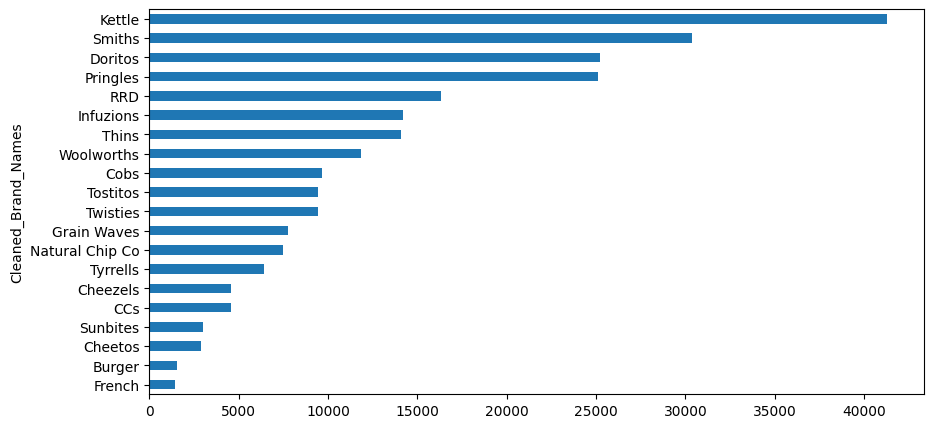

In [31]:
merged_data["Cleaned_Brand_Names"].value_counts(ascending=True).plot.barh(figsize=(10,5))

In [32]:
merged_data.isnull().sum()

DATE                   0
STORE_NBR              0
LYLTY_CARD_NBR         0
TXN_ID                 0
PROD_NBR               0
PROD_NAME              0
PROD_QTY               0
TOT_SALES              0
LIFESTAGE              0
PREMIUM_CUSTOMER       0
Cleaned_Brand_Names    0
dtype: int64

- Who spends the most on chips (total sales), describing customers by lifestage and
how premium their general purchasing behaviour is
- How many customers are in each segment
- How many chips are bought per customer by segment
- What's the average chip price by customer segment

In [33]:
grouped_sales = pd.DataFrame(merged_data.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["TOT_SALES"].agg(["sum", "mean"]))
grouped_sales.sort_values(ascending=False, by="sum")

sum      mean
LIFESTAGE              PREMIUM_CUSTOMER                     
OLDER FAMILIES         Budget            156863.75  7.291241
YOUNG SINGLES/COUPLES  Mainstream        147582.20  7.551279
RETIREES               Mainstream        145168.95  7.269352
YOUNG FAMILIES         Budget            129717.95  7.302705
OLDER SINGLES/COUPLES  Budget            127833.60  7.444305
                       Mainstream        124648.50  7.306049
                       Premium           123537.55  7.459997
RETIREES               Budget            105916.30  7.445786
OLDER FAMILIES         Mainstream         96413.55  7.281440
RETIREES               Premium            91296.65  7.461315
YOUNG FAMILIES         Mainstream         86338.25  7.226772
MIDAGE SINGLES/COUPLES Mainstream         84734.25  7.637156
YOUNG FAMILIES         Premium            78571.70  7.285951
OLDER FAMILIES         Premium            75242.60  7.232779
YOUNG SINGLES/COUPLES  Budget             57122.10  6.663023
MIDAGE SINGLES/COUPLES Premium            54443.85  7.152371
YOUNG SINGLES/COUPLES  Premium            39052.30  6.673325
MIDAGE SINGLES/COUPLES Budget             33345.70  7.108442
NEW FAMILIES           Budget             20607.45  7.297256
                       Mainstream         15979.70  7.313364
                       Premium            10760.80  7.231720

In [34]:
grouped_sales["sum"].sum()

1805177.7

<Axes: ylabel='LIFESTAGE,PREMIUM_CUSTOMER'>

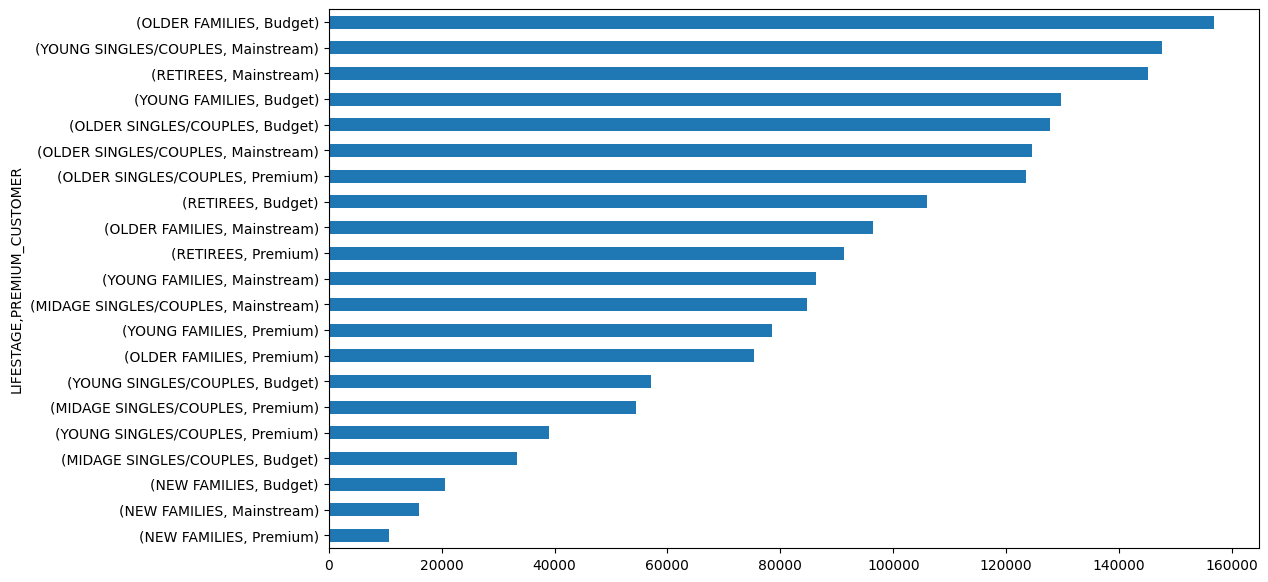

In [35]:
grouped_sales["sum"].sort_values().plot.barh(figsize=(12,7))

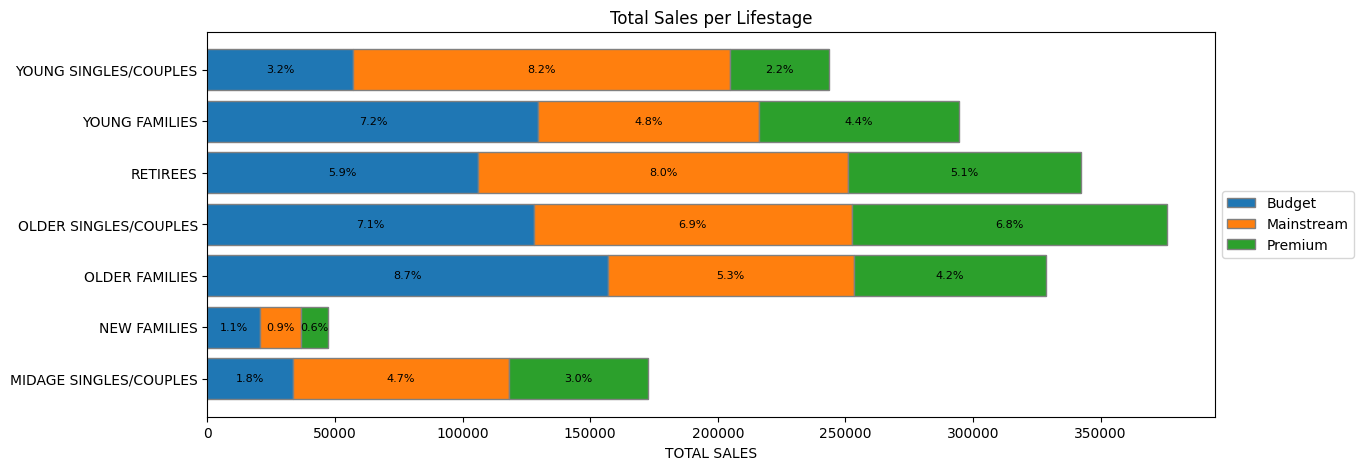

In [36]:
# Align Budget/Mainstream/Premium by LIFESTAGE before stacking.
sales_by_stage = grouped_sales["sum"].unstack("PREMIUM_CUSTOMER").fillna(0)
names = sales_by_stage.index.tolist()
r = np.arange(len(names))
budget = sales_by_stage["Budget"].to_numpy()
mainstream = sales_by_stage["Mainstream"].to_numpy()
premium = sales_by_stage["Premium"].to_numpy()
total_sales = sales_by_stage.to_numpy().sum()
plt.figure(figsize=(13, 5))
plt.barh(r, budget, label="Budget", edgecolor="grey")
plt.barh(r, mainstream, left=budget, label="Mainstream", edgecolor="grey")
plt.barh(r, premium, left=budget + mainstream, label="Premium", edgecolor="grey")
for i in range(len(names)):
    plt.text(budget[i] / 2, i, f"{budget[i] / total_sales:.1%}", ha="center", va="center", size=8)
    plt.text(budget[i] + mainstream[i] / 2, i, f"{mainstream[i] / total_sales:.1%}", ha="center", va="center", size=8)
    plt.text(budget[i] + mainstream[i] + premium[i] / 2, i, f"{premium[i] / total_sales:.1%}", ha="center", va="center", size=8)
plt.yticks(r, names)
plt.xlabel("TOTAL SALES")
plt.title("Total Sales per Lifestage")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.savefig("lifestage_sales.png", bbox_inches="tight")
plt.show()


In [37]:
stage_agg_prem = merged_data.groupby("LIFESTAGE")["PREMIUM_CUSTOMER"].agg(pd.Series.mode).sort_values()
print("Top contributor per LIFESTAGE by PREMIUM category")
print(stage_agg_prem)

Top contributor per LIFESTAGE by PREMIUM category
LIFESTAGE
NEW FAMILIES                  Budget
OLDER FAMILIES                Budget
OLDER SINGLES/COUPLES         Budget
YOUNG FAMILIES                Budget
MIDAGE SINGLES/COUPLES    Mainstream
RETIREES                  Mainstream
YOUNG SINGLES/COUPLES     Mainstream
Name: PREMIUM_CUSTOMER, dtype: object


The top 3 total sales contributor segment are (in order):
- Older families (Budget) \$156,864
- Young Singles/Couples (Mainstream) \$147,582
- Retirees (Mainstream) \$145,169

In [38]:
unique_cust = merged_data.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["LYLTY_CARD_NBR"].nunique().sort_values(ascending=False)
pd.DataFrame(unique_cust)

LYLTY_CARD_NBR
LIFESTAGE              PREMIUM_CUSTOMER                
YOUNG SINGLES/COUPLES  Mainstream                  7917
RETIREES               Mainstream                  6358
OLDER SINGLES/COUPLES  Mainstream                  4858
                       Budget                      4849
                       Premium                     4682
OLDER FAMILIES         Budget                      4611
RETIREES               Budget                      4385
YOUNG FAMILIES         Budget                      3953
RETIREES               Premium                     3812
YOUNG SINGLES/COUPLES  Budget                      3647
MIDAGE SINGLES/COUPLES Mainstream                  3298
OLDER FAMILIES         Mainstream                  2788
YOUNG FAMILIES         Mainstream                  2685
YOUNG SINGLES/COUPLES  Premium                     2480
YOUNG FAMILIES         Premium                     2398
MIDAGE SINGLES/COUPLES Premium                     2369
OLDER FAMILIES         Premium                     2231
MIDAGE SINGLES/COUPLES Budget                      1474
NEW FAMILIES           Budget                      1087
                       Mainstream                   830
                       Premium                      575

<Axes: ylabel='LIFESTAGE,PREMIUM_CUSTOMER'>

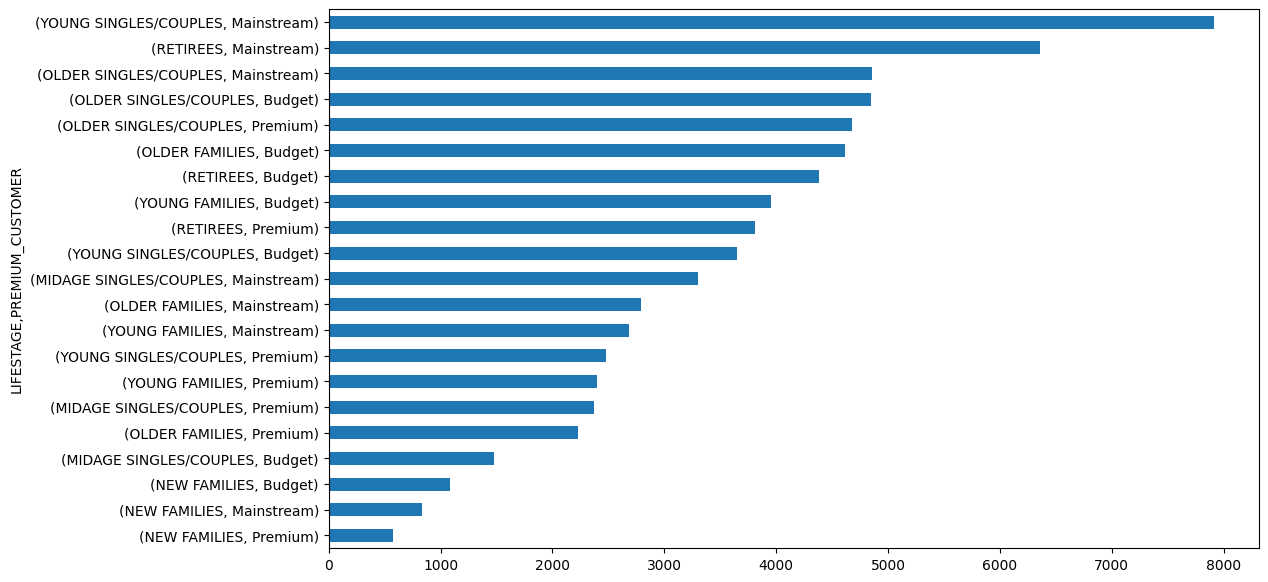

In [39]:
unique_cust.sort_values().plot.barh(figsize=(12,7))

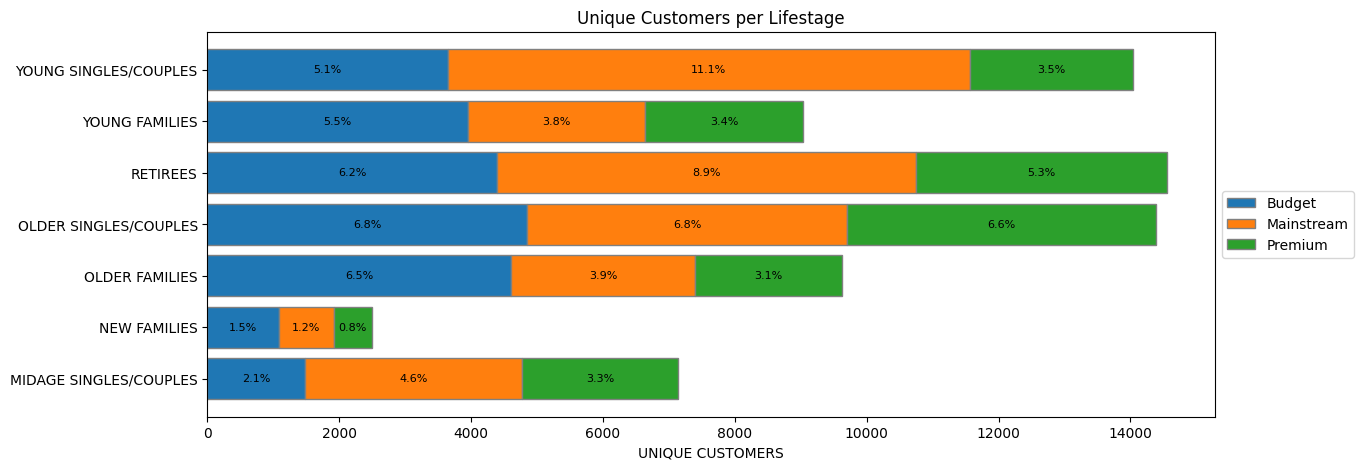

In [40]:
# Align customer counts by LIFESTAGE before stacking.
customers_by_stage = unique_cust.unstack("PREMIUM_CUSTOMER").fillna(0).reindex(names)
budget = customers_by_stage["Budget"].to_numpy()
mainstream = customers_by_stage["Mainstream"].to_numpy()
premium = customers_by_stage["Premium"].to_numpy()
total_customers = customers_by_stage.to_numpy().sum()
plt.figure(figsize=(13, 5))
plt.barh(r, budget, label="Budget", edgecolor="grey")
plt.barh(r, mainstream, left=budget, label="Mainstream", edgecolor="grey")
plt.barh(r, premium, left=budget + mainstream, label="Premium", edgecolor="grey")
for i in range(len(names)):
    plt.text(budget[i] / 2, i, f"{budget[i] / total_customers:.1%}", ha="center", va="center", size=8)
    plt.text(budget[i] + mainstream[i] / 2, i, f"{mainstream[i] / total_customers:.1%}", ha="center", va="center", size=8)
    plt.text(budget[i] + mainstream[i] + premium[i] / 2, i, f"{premium[i] / total_customers:.1%}", ha="center", va="center", size=8)
plt.yticks(r, names)
plt.xlabel("UNIQUE CUSTOMERS")
plt.title("Unique Customers per Lifestage")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()


The high sales amount by segment "Young Singles/Couples - Mainstream" and "Retirees - Mainstream" are due to their large number of unique customers, but not for the "Older - Budget" segment. Next we'll explore if the "Older - Budget" segment has:
- High Frequency of Purchase and,
- Average Sales per Customer compared to the other segment.

In [41]:
# Count unique purchases, not product rows. TXN_ID alone is reused in a few rows.
purchase_key = ["STORE_NBR", "LYLTY_CARD_NBR", "DATE", "TXN_ID"]
merged_data["purchase_id"] = pd.MultiIndex.from_frame(merged_data[purchase_key]).factorize()[0]
freq_per_cust = merged_data.groupby(["LYLTY_CARD_NBR", "LIFESTAGE", "PREMIUM_CUSTOMER"])["purchase_id"].nunique()
freq_per_cust.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"]).agg(["mean", "count"]).sort_values(ascending=False, by="mean")


mean  count
LIFESTAGE              PREMIUM_CUSTOMER                 
OLDER FAMILIES         Mainstream        4.709828   2788
                       Budget            4.624376   4611
                       Premium           4.617660   2231
YOUNG FAMILIES         Premium           4.462886   2398
                       Budget            4.459651   3953
                       Mainstream        4.417132   2685
OLDER SINGLES/COUPLES  Budget            3.521963   4849
                       Premium           3.518155   4682
                       Mainstream        3.490737   4858
MIDAGE SINGLES/COUPLES Mainstream        3.345664   3298
RETIREES               Budget            3.226226   4385
                       Premium           3.195173   3812
MIDAGE SINGLES/COUPLES Premium           3.192908   2369
                       Budget            3.162144   1474
RETIREES               Mainstream        3.126455   6358
NEW FAMILIES           Mainstream        2.627711    830
                       Budget            2.587856   1087
                       Premium           2.579130    575
YOUNG SINGLES/COUPLES  Mainstream        2.460781   7917
                       Premium           2.352419   2480
                       Budget            2.343570   3647

The table now counts unique transactions per customer. Older Families still have the highest average purchase frequency; the Budget subgroup's estimate is about 4.62 transactions per customer, rather than 4.67 product rows.


In [42]:
grouped_sales.sort_values(ascending=False, by="mean")

,,sum,mean
LIFESTAGE,PREMIUM_CUSTOMER,,
MIDAGE SINGLES/COUPLES,Mainstream,84734.25,7.637156
YOUNG SINGLES/COUPLES,Mainstream,147582.20,7.551279
RETIREES,Premium,91296.65,7.461315
OLDER SINGLES/COUPLES,Premium,123537.55,7.459997
RETIREES,Budget,105916.30,7.445786
OLDER SINGLES/COUPLES,Budget,127833.60,7.444305
NEW FAMILIES,Mainstream,15979.70,7.313364
OLDER SINGLES/COUPLES,Mainstream,124648.50,7.306049
YOUNG FAMILIES,Budget,129717.95,7.302705


Highest average spending per purchase are contributed by the Midage and Young "Singles/Couples". The difference between their Mainstream and Non-Mainstream group might seem insignificant (7.6 vs 6.6), but we'll find out by examining if the difference is statistically significant.

In [43]:
from scipy.stats import ttest_ind

In [44]:
mainstream = merged_data["PREMIUM_CUSTOMER"] == "Mainstream"
young_midage = (merged_data["LIFESTAGE"] == "MIDAGE SINGLES/COUPLES") | (merged_data["LIFESTAGE"] == "YOUNG SINGLES/COUPLES")

budget_premium = (merged_data["PREMIUM_CUSTOMER"] == "Budget") | (merged_data["PREMIUM_CUSTOMER"] == "Premium")

a = merged_data[young_midage & mainstream]["TOT_SALES"]
b = merged_data[young_midage & budget_premium]["TOT_SALES"]
stat, pval = ttest_ind(a.values, b.values, equal_var=False)

print(pval)
pval < 0.0000001

1.8346459081808283e-237


True

P-Value is close to 0. There is a statistically significant difference to the Total Sales between the "Mainstream Young Midage" segment to the "Budget and Premium Young Midage" segment.

Next, let's look examine what brand of chips the top 3 segments contributing to Total Sales are buying.

In [45]:
merged_data.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["Cleaned_Brand_Names"].agg(pd.Series.mode).sort_values()

LIFESTAGE               PREMIUM_CUSTOMER
MIDAGE SINGLES/COUPLES  Budget              Kettle
YOUNG SINGLES/COUPLES   Budget              Kettle
YOUNG FAMILIES          Premium             Kettle
                        Mainstream          Kettle
                        Budget              Kettle
RETIREES                Premium             Kettle
                        Mainstream          Kettle
                        Budget              Kettle
OLDER SINGLES/COUPLES   Premium             Kettle
YOUNG SINGLES/COUPLES   Mainstream          Kettle
OLDER SINGLES/COUPLES   Mainstream          Kettle
OLDER FAMILIES          Premium             Kettle
                        Mainstream          Kettle
                        Budget              Kettle
NEW FAMILIES            Premium             Kettle
                        Mainstream          Kettle
                        Budget              Kettle
MIDAGE SINGLES/COUPLES  Premium             Kettle
                        Mainstream       

========== YOUNG SINGLES/COUPLES - Premium ==========
Cleaned_Brand_Names
Kettle      838
Smiths      787
Pringles    537
Name: count, dtype: int64


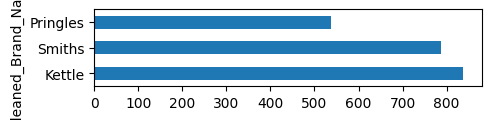

========== YOUNG SINGLES/COUPLES - Budget ==========
Cleaned_Brand_Names
Kettle      1211
Smiths      1185
Pringles     832
Name: count, dtype: int64


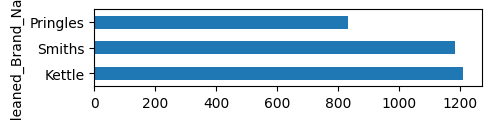

========== YOUNG SINGLES/COUPLES - Mainstream ==========
Cleaned_Brand_Names
Kettle      3844
Doritos     2379
Pringles    2315
Name: count, dtype: int64


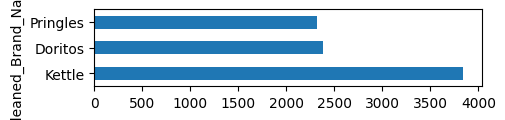

========== MIDAGE SINGLES/COUPLES - Premium ==========
Cleaned_Brand_Names
Kettle      1206
Smiths       923
Pringles     781
Name: count, dtype: int64


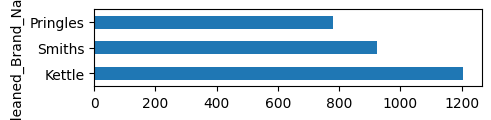

========== MIDAGE SINGLES/COUPLES - Budget ==========
Cleaned_Brand_Names
Kettle     713
Smiths     591
Doritos    479
Name: count, dtype: int64


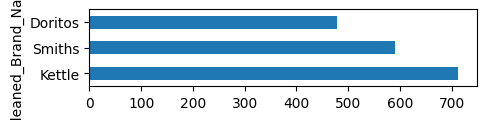

========== MIDAGE SINGLES/COUPLES - Mainstream ==========


Cleaned_Brand_Names
Kettle     2136
Smiths     1276
Doritos    1210
Name: count, dtype: int64


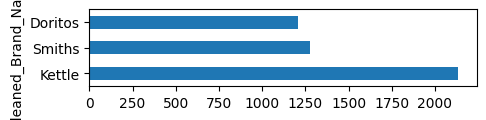

========== NEW FAMILIES - Premium ==========
Cleaned_Brand_Names
Kettle      247
Pringles    165
Smiths      155
Name: count, dtype: int64


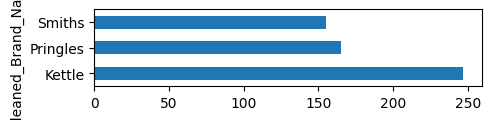

========== NEW FAMILIES - Budget ==========


Cleaned_Brand_Names
Kettle     510
Smiths     328
Doritos    315
Name: count, dtype: int64


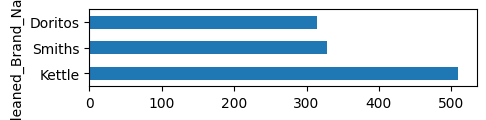

========== NEW FAMILIES - Mainstream ==========


Cleaned_Brand_Names
Kettle     414
Doritos    257
Smiths     244
Name: count, dtype: int64


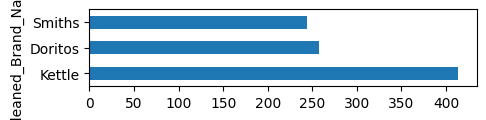

========== OLDER FAMILIES - Premium ==========


Cleaned_Brand_Names
Kettle      1512
Smiths      1448
Pringles    1014
Name: count, dtype: int64


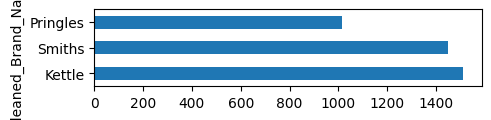

========== OLDER FAMILIES - Budget ==========


Cleaned_Brand_Names
Kettle     3320
Smiths     2948
Doritos    2032
Name: count, dtype: int64


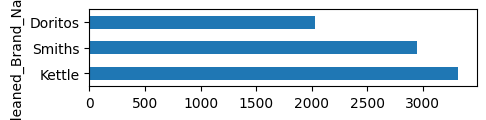

========== OLDER FAMILIES - Mainstream ==========


Cleaned_Brand_Names
Kettle     2019
Smiths     1742
Doritos    1263
Name: count, dtype: int64


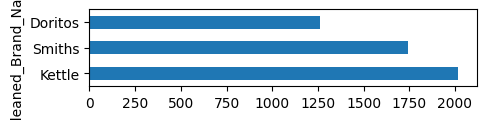

========== OLDER SINGLES/COUPLES - Premium ==========


Cleaned_Brand_Names
Kettle     2947
Smiths     1952
Doritos    1784
Name: count, dtype: int64


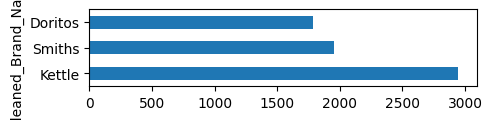

========== OLDER SINGLES/COUPLES - Budget ==========


Cleaned_Brand_Names
Kettle      3065
Smiths      2010
Pringles    1843
Name: count, dtype: int64


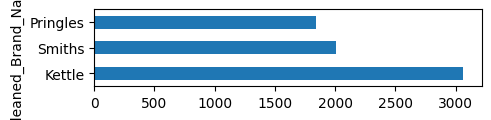

========== OLDER SINGLES/COUPLES - Mainstream ==========


Cleaned_Brand_Names
Kettle     2835
Smiths     2070
Doritos    1791
Name: count, dtype: int64


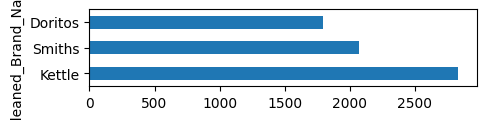

========== RETIREES - Premium ==========


Cleaned_Brand_Names
Kettle      2216
Smiths      1395
Pringles    1331
Name: count, dtype: int64


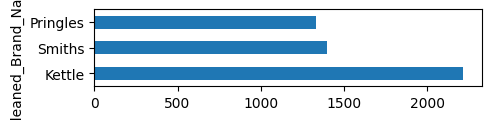

========== RETIREES - Budget ==========


Cleaned_Brand_Names
Kettle     2592
Smiths     1612
Doritos    1592
Name: count, dtype: int64


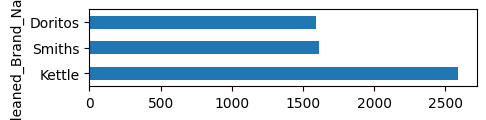

========== RETIREES - Mainstream ==========


Cleaned_Brand_Names
Kettle      3386
Smiths      2367
Pringles    2103
Name: count, dtype: int64

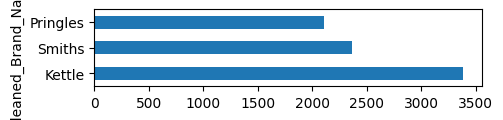

========== YOUNG FAMILIES - Premium ==========


Cleaned_Brand_Names
Kettle      1745
Smiths      1384
Pringles    1007
Name: count, dtype: int64


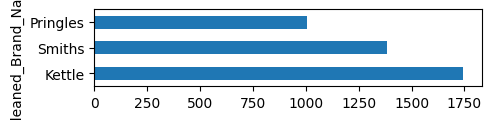

========== YOUNG FAMILIES - Budget ==========


Cleaned_Brand_Names
Kettle     2743
Smiths     2334
Doritos    1767
Name: count, dtype: int64


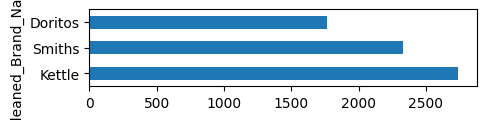

========== YOUNG FAMILIES - Mainstream ==========


Cleaned_Brand_Names
Kettle      1789
Smiths      1681
Pringles    1148
Name: count, dtype: int64


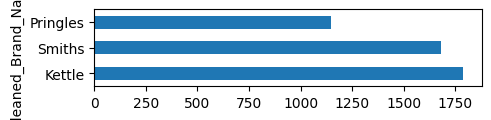

In [46]:
for stage in merged_data["LIFESTAGE"].unique():
    for prem in merged_data["PREMIUM_CUSTOMER"].unique():
        print('==========',stage, '-', prem,'==========')
        summary = merged_data[(merged_data["LIFESTAGE"] == stage) & (merged_data["PREMIUM_CUSTOMER"] == prem)]["Cleaned_Brand_Names"].value_counts().head(3)
        print(summary)
        plt.figure()
        summary.plot.barh(figsize=(5,1))
        plt.show()

Every segment had Kettle as the most purchased brand. Every segment except "YOUNG SINGLES/COUPLES Mainstream" had Smiths as their second most purchased brand. "YOUNG SINGLES/COUPLES Mainstream" had Doritos as their second most purchased brand.

In [47]:
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

In [48]:
temp = merged_data.reset_index().rename(columns={"index": "source_row"})
temp["Segment"] = temp["LIFESTAGE"] + " - " + temp["PREMIUM_CUSTOMER"]
segment_brand_encode = pd.concat([pd.get_dummies(temp["Segment"]), pd.get_dummies(temp["Cleaned_Brand_Names"])], axis=1)


In [49]:
frequent_sets = apriori(segment_brand_encode, min_support=0.01, use_colnames=True)
rules = association_rules(frequent_sets, metric="lift", min_threshold=1)

In [50]:
set_temp = temp["Segment"].unique()
rules[rules["antecedents"].apply(lambda x: list(x)).apply(lambda x: x in set_temp)]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1,(OLDER FAMILIES - Budget),(Smiths),0.087193,0.123016,0.011948,0.137027,1.113895,1.0,0.001222,1.016236,0.112016,0.060263,0.015976,0.117075
2,(OLDER SINGLES/COUPLES - Budget),(Kettle),0.069596,0.167334,0.012422,0.178488,1.066658,1.0,0.000776,1.013578,0.067167,0.055330,0.013396,0.126361
5,(OLDER SINGLES/COUPLES - Premium),(Kettle),0.067115,0.167334,0.011944,0.177959,1.063495,1.0,0.000713,1.012925,0.064000,0.053678,0.012760,0.124668
6,(RETIREES - Budget),(Kettle),0.057652,0.167334,0.010505,0.182214,1.088926,1.0,0.000858,1.018196,0.086660,0.048979,0.017871,0.122496
8,(RETIREES - Mainstream),(Kettle),0.080935,0.167334,0.013723,0.169554,1.013269,1.0,0.000180,1.002674,0.014248,0.058508,0.002666,0.125782
10,(YOUNG SINGLES/COUPLES - Mainstream),(Kettle),0.079209,0.167334,0.015579,0.196684,1.175400,1.0,0.002325,1.036537,0.162062,0.067453,0.035249,0.144893


By looking at our a-priori analysis, we can conclude that Kettle is the brand of choice for most segment.

Next, we'll find out the pack size preferences of different segments

========== YOUNG SINGLES/COUPLES - Premium ==========
Pack_Size
134     537
150     933
175    1618
Name: count, dtype: int64


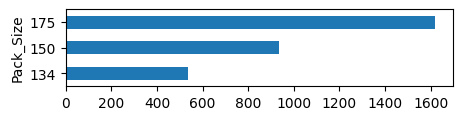

========== YOUNG SINGLES/COUPLES - Budget ==========
Pack_Size
134     832
150    1390
175    2338
Name: count, dtype: int64


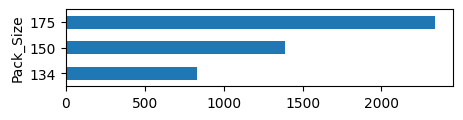

========== YOUNG SINGLES/COUPLES - Mainstream ==========
Pack_Size
134    2315
150    3080
175    4997
Name: count, dtype: int64


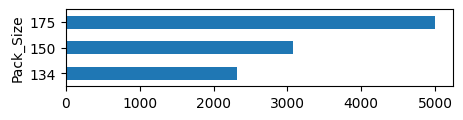

========== MIDAGE SINGLES/COUPLES - Premium ==========
Pack_Size
134     781
150    1207
175    2082
Name: count, dtype: int64


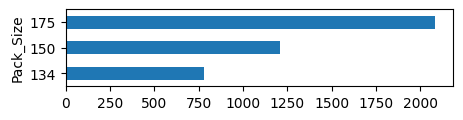

========== MIDAGE SINGLES/COUPLES - Budget ==========
Pack_Size
134     449
150     771
175    1277
Name: count, dtype: int64


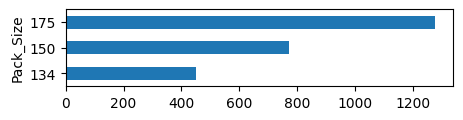

========== MIDAGE SINGLES/COUPLES - Mainstream ==========
Pack_Size
134    1159
150    1777
175    2975
Name: count, dtype: int64


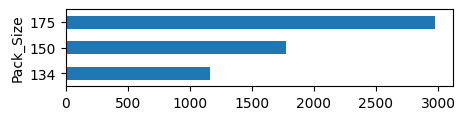

========== NEW FAMILIES - Premium ==========
Pack_Size
134    165
150    233
175    376
Name: count, dtype: int64


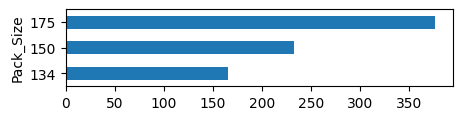

========== NEW FAMILIES - Budget ==========
Pack_Size
134    309
150    440
175    777
Name: count, dtype: int64


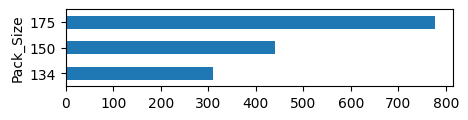

========== NEW FAMILIES - Mainstream ==========
Pack_Size
134    224
150    374
175    589
Name: count, dtype: int64


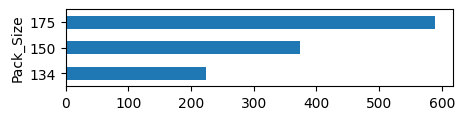

========== OLDER FAMILIES - Premium ==========
Pack_Size
134    1014
150    1673
175    2816
Name: count, dtype: int64


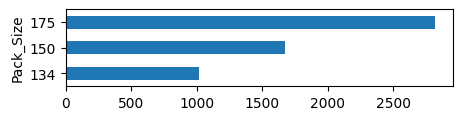

========== OLDER FAMILIES - Budget ==========
Pack_Size
134    1996
150    3588
175    5808
Name: count, dtype: int64


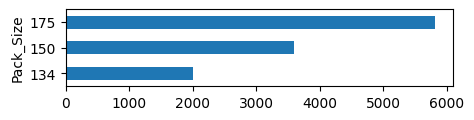

========== OLDER FAMILIES - Mainstream ==========
Pack_Size
134    1234
150    2189
175    3588
Name: count, dtype: int64


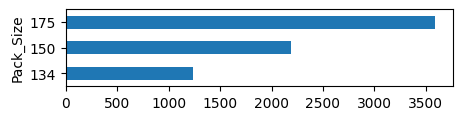

========== OLDER SINGLES/COUPLES - Premium ==========
Pack_Size
134    1744
150    2768
175    4458
Name: count, dtype: int64


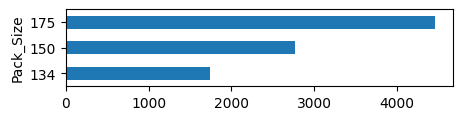

========== OLDER SINGLES/COUPLES - Budget ==========
Pack_Size
134    1843
150    2811
175    4625
Name: count, dtype: int64


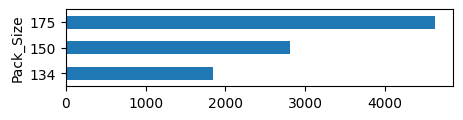

========== OLDER SINGLES/COUPLES - Mainstream ==========
Pack_Size
134    1720
150    2773
175    4525
Name: count, dtype: int64


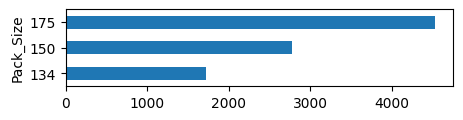

========== RETIREES - Premium ==========
Pack_Size
134    1331
150    1943
175    3306
Name: count, dtype: int64


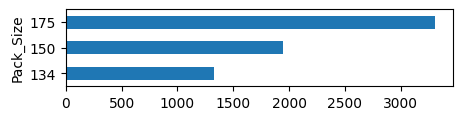

========== RETIREES - Budget ==========
Pack_Size
134    1517
150    2319
175    3847
Name: count, dtype: int64


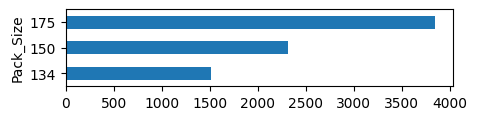

========== RETIREES - Mainstream ==========
Pack_Size
134    2103
150    3290
175    5295
Name: count, dtype: int64


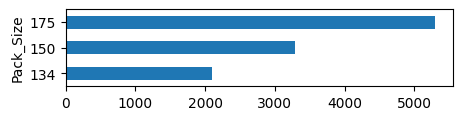

========== YOUNG FAMILIES - Premium ==========
Pack_Size
134    1007
150    1778
175    2998
Name: count, dtype: int64


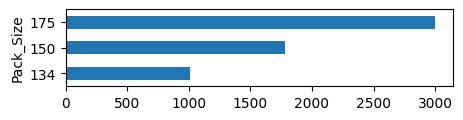

========== YOUNG FAMILIES - Budget ==========
Pack_Size
134    1674
150    2862
175    4921
Name: count, dtype: int64


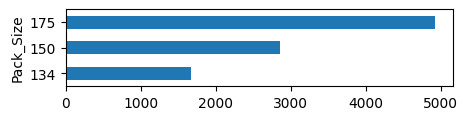

========== YOUNG FAMILIES - Mainstream ==========
Pack_Size
134    1148
150    2004
175    3174
Name: count, dtype: int64


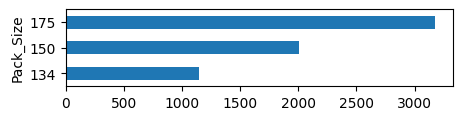

In [51]:
merged_pack = pd.concat([merged_data, pack_sizes.rename("Pack_Size")], axis=1)

for stage in merged_data["LIFESTAGE"].unique():
    for prem in merged_data["PREMIUM_CUSTOMER"].unique():
        print('==========',stage, '-', prem,'==========')
        summary = merged_pack[(merged_pack["LIFESTAGE"] == stage) & (merged_pack["PREMIUM_CUSTOMER"] == prem)]["Pack_Size"].value_counts().head(3).sort_index()
        print(summary)
        plt.figure()
        summary.plot.barh(figsize=(5,1))
        plt.show()

All of the segments prefer the 175gr pack size chips, followed by the 150gr size.

Next, let's find out average amount of chips bought per customer segment.

In [52]:
(temp.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["PROD_QTY"].sum() / temp.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["LYLTY_CARD_NBR"].nunique()).sort_values(ascending=False)

LIFESTAGE               PREMIUM_CUSTOMER
OLDER FAMILIES          Mainstream          9.255380
                        Budget              9.076773
                        Premium             9.071717
YOUNG FAMILIES          Budget              8.722995
                        Premium             8.716013
                        Mainstream          8.638361
OLDER SINGLES/COUPLES   Budget              6.781398
                        Premium             6.769543
                        Mainstream          6.712021
MIDAGE SINGLES/COUPLES  Mainstream          6.432080
RETIREES                Budget              6.141847
                        Premium             6.103358
MIDAGE SINGLES/COUPLES  Premium             6.078514
                        Budget              6.026459
RETIREES                Mainstream          5.925920
NEW FAMILIES            Mainstream          4.891566
                        Budget              4.821527
                        Premium             4.815652
YOUNG

In [53]:
# Customer-segment business measures.
segment_metrics = merged_data.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"]).agg(
    total_sales=("TOT_SALES", "sum"), customers=("LYLTY_CARD_NBR", "nunique"),
    transactions=("purchase_id", "nunique"), units=("PROD_QTY", "sum"))
segment_metrics["transactions_per_customer"] = segment_metrics.transactions / segment_metrics.customers
segment_metrics["units_per_transaction"] = segment_metrics.units / segment_metrics.transactions
segment_metrics["sales_per_customer"] = segment_metrics.total_sales / segment_metrics.customers
segment_metrics["sales_per_transaction"] = segment_metrics.total_sales / segment_metrics.transactions
segment_metrics["weighted_price_per_unit"] = segment_metrics.total_sales / segment_metrics.units
customer_transactions = merged_data.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER", "LYLTY_CARD_NBR"]).purchase_id.nunique()
repeat_rate = customer_transactions.ge(2).groupby(level=[0,1]).mean()
segment_metrics["repeat_customer_rate"] = repeat_rate
assert np.allclose(segment_metrics.total_sales,
    segment_metrics.customers * segment_metrics.transactions_per_customer * segment_metrics.sales_per_transaction)
segment_metrics.sort_values("total_sales", ascending=False).head(3).round(3)


,,total_sales,customers,transactions,units,transactions_per_customer,units_per_transaction,sales_per_customer,sales_per_transaction,weighted_price_per_unit,repeat_customer_rate
LIFESTAGE,PREMIUM_CUSTOMER,,,,,,,,,,
OLDER FAMILIES,Budget,156863.75,4611,21323,41853,4.624,1.963,34.019,7.357,3.748,0.790
YOUNG SINGLES/COUPLES,Mainstream,147582.20,7917,19482,36225,2.461,1.859,18.641,7.575,4.074,0.631
RETIREES,Mainstream,145168.95,6358,19878,37677,3.126,1.895,22.832,7.303,3.853,0.723


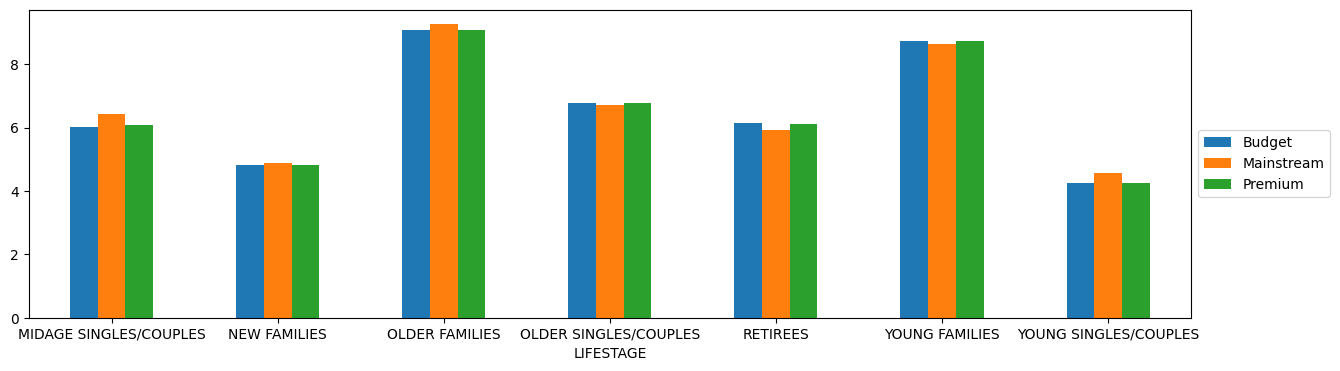

In [54]:
(temp.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["PROD_QTY"].sum() / temp.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["LYLTY_CARD_NBR"].nunique()).unstack().plot.bar(figsize=(15,4), rot=0)
plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.savefig("Average purchase quantity per segment.png", bbox_inches="tight")

In [55]:
# Weighted price per pack is a more useful segment comparison than an unweighted mean of row prices.
temp["Unit_Price"] = temp["TOT_SALES"] / temp["PROD_QTY"]
weighted_unit_price = temp.groupby("Segment")["TOT_SALES"].sum() / temp.groupby("Segment")["PROD_QTY"].sum()
weighted_unit_price.sort_values(ascending=False)


Segment
YOUNG SINGLES/COUPLES - Mainstream     4.074043
MIDAGE SINGLES/COUPLES - Mainstream    3.994449
NEW FAMILIES - Mainstream              3.935887
RETIREES - Budget                      3.932731
NEW FAMILIES - Budget                  3.931969
RETIREES - Premium                     3.924037
OLDER SINGLES/COUPLES - Premium        3.897698
OLDER SINGLES/COUPLES - Budget         3.887529
NEW FAMILIES - Premium                 3.886168
RETIREES - Mainstream                  3.852986
OLDER SINGLES/COUPLES - Mainstream     3.822753
MIDAGE SINGLES/COUPLES - Premium       3.780823
YOUNG FAMILIES - Budget                3.761903
YOUNG FAMILIES - Premium               3.759232
MIDAGE SINGLES/COUPLES - Budget        3.753878
OLDER FAMILIES - Budget                3.747969
OLDER FAMILIES - Mainstream            3.736380
YOUNG FAMILIES - Mainstream            3.722439
OLDER FAMILIES - Premium               3.717703
YOUNG SINGLES/COUPLES - Premium        3.692889
YOUNG SINGLES/COUPLES - Budget  

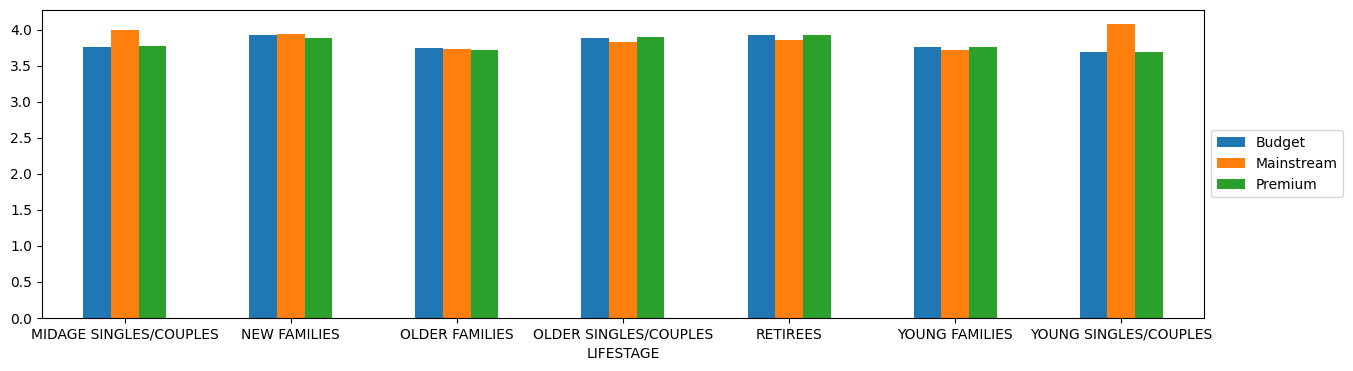

In [56]:
weighted_unit_price.rename("Unit_Price").reset_index().assign(
    LIFESTAGE=lambda x: x.Segment.str.rsplit(" - ", n=1).str[0],
    PREMIUM_CUSTOMER=lambda x: x.Segment.str.rsplit(" - ", n=1).str[1],
).pivot(index="LIFESTAGE", columns="PREMIUM_CUSTOMER", values="Unit_Price").plot.bar(figsize=(15,4), rot=0)
plt.legend(loc="center left", bbox_to_anchor=(1,0.5))


# Insights

- Top sales segments are Older Families / Budget ($156,863.75), Young Singles/Couples / Mainstream ($147,582.20), and Retirees / Mainstream ($145,168.95).
- Young Singles/Couples / Mainstream and Retirees / Mainstream benefit from large customer counts. Older Families / Budget also benefit from higher repeat purchase frequency, measured using unique transactions.
- Segment metrics separate customer count, transactions per customer, units per transaction, sales per transaction, weighted unit price and repeat-customer rate. This decomposition shows which driver contributes to total sales.
- Kettle leads brand counts in every segment. Young Singles/Couples / Mainstream have Doritos second; this claim should not be extended to every Midage Singles/Couples segment.
- 175g is the most common pack size, followed by 150g. Promotional ideas below require a separate test; historical sales do not establish uplift.


# Reccomendations:
- Older Families:
    - Focus on the Budget segment.
    - Strength: Frequent purchase. We can give promotions that encourages more frequency of purchase.
    - Strength: High quantity of chips purchased per visit. We can give promotions that encourage them to buy more quantity of chips per purchase.
- Young Singles/Couples:
    - Focus on the Mainstream segment.
    - This segment is the only segment that had Doritos as their 2nd most purchased brand (after Kettle). To specifically target this segment it might be a good idea to collaborate with Doritos merchant to do some branding promotion catered to "Young Singles/Couples - Mainstream" segment.
    - Strength: Population quantity. We can spend more effort on making sure our promotions reach them, and it reaches them frequently.
- Retirees:
    - Focus on the Mainstream segment.
    - Strength: Population quantity. Again, since their population quantity is the contributor to the high total sales, we should spend more effort on making sure our promotions reaches as many of them as possible and frequent.
- General:
    - All segments has Kettle as the most frequently purchased brand, and 175gr (regardless of brand) followed by 150gr as the preferred chip size.
    - When promoting chips in general to all segments it is good to take advantage of these two points.

In [57]:
z = temp.groupby(["Segment", "Cleaned_Brand_Names"])["TOT_SALES"].sum().sort_values(ascending=False).reset_index()
z[z["Segment"] == "YOUNG SINGLES/COUPLES - Mainstream"]


,Segment,Cleaned_Brand_Names,TOT_SALES
0,YOUNG SINGLES/COUPLES - Mainstream,Kettle,35423.6
8,YOUNG SINGLES/COUPLES - Mainstream,Doritos,20925.9
22,YOUNG SINGLES/COUPLES - Mainstream,Pringles,16006.2
24,YOUNG SINGLES/COUPLES - Mainstream,Smiths,14958.9
54,YOUNG SINGLES/COUPLES - Mainstream,Infuzions,8749.4
61,YOUNG SINGLES/COUPLES - Mainstream,Twisties,7539.8
69,YOUNG SINGLES/COUPLES - Mainstream,Tostitos,7238.0
70,YOUNG SINGLES/COUPLES - Mainstream,Thins,7217.1
84,YOUNG SINGLES/COUPLES - Mainstream,Cobs,6144.6
115,YOUNG SINGLES/COUPLES - Mainstream,Tyrrells,4800.6
